# Post-Earnings Announcement Drift (PEAD) Analysis

Does a stock keep drifting after it beats or misses earnings, or does the market just
reprice instantly and move on? And is that effect actually stronger in smaller,
less-covered stocks, the way the literature claims?

This notebook walks through what I found: 2,953 earnings events across 60 stocks (20
large/20 mid/20 small-cap), tested well over a dozen different ways, plus a separate track
on earnings-day volatility and options pricing that's closer to how I actually trade around
these dates. `README.md` in this repo has the full methodology writeup; this notebook is
more of a results tour, with the actual charts and tables rendered inline so you don't have
to run anything to see them.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

try:
    db_url = (
        f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}"
        f"@{os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}/{os.environ['POSTGRES_DB']}"
    )
    engine = create_engine(db_url)
    df = pd.read_sql("SELECT * FROM earnings_drift", engine)
    print("Loaded from live database.")
except Exception:
    df = pd.read_csv("snapshot/earnings_drift.csv", parse_dates=["reported_date", "day0_date"])
    print("Loaded from static snapshot (no live database available).")

print(f"{len(df)} earnings events, {df['symbol'].nunique()} tickers, "
      f"{df['tier'].nunique()} tiers")


Loaded from live database.
2953 earnings events, 60 tickers, 3 tiers


## Sample composition

Three market-cap tiers, 20 tickers each, spread across Tech, Financials, Healthcare,
Consumer, Defense, and Industrials so no single sector dominates any tier.


In [2]:
tier_summary = df.groupby("tier").agg(events=("symbol", "count"), tickers=("symbol", "nunique"))
tier_summary.loc[["large", "mid", "small"]]


,events,tickers
tier,,
large,1237,20
mid,835,20
small,881,20


## 1. Does surprise size predict abnormal drift?

I bucketed every event into quintiles by surprise size, biggest miss to biggest beat, and
checked the average abnormal (market-adjusted) drift 10 trading days later. If PEAD were
real, this should look like a clean staircase: negative drift for big misses, positive for
big beats.


In [3]:
df_clean = df.dropna(subset=["surprise_percentage", "abnormal_drift_10d_pct"]).copy()
df_clean["surprise_quintile"] = pd.qcut(
    df_clean["surprise_percentage"], 5,
    labels=["1: Big miss", "2: Miss", "3: Meet", "4: Beat", "5: Big beat"],
)

bucket_stats = df_clean.groupby("surprise_quintile", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "median_surprise_pct": g["surprise_percentage"].median(),
        "avg_abnormal_drift_10d_pct": g["abnormal_drift_10d_pct"].mean(),
        "p_value": stats.ttest_1samp(g["abnormal_drift_10d_pct"], 0).pvalue,
    }), include_groups=False,
)
bucket_stats.round(3)


,n,median_surprise_pct,avg_abnormal_drift_10d_pct,p_value
surprise_quintile,,,,
1: Big miss,591.0,-10.714,0.183,0.538
2: Miss,590.0,1.455,0.618,0.015
3: Meet,591.0,6.430,0.030,0.890
4: Beat,590.0,15.000,0.116,0.675
5: Big beat,591.0,46.770,0.246,0.475


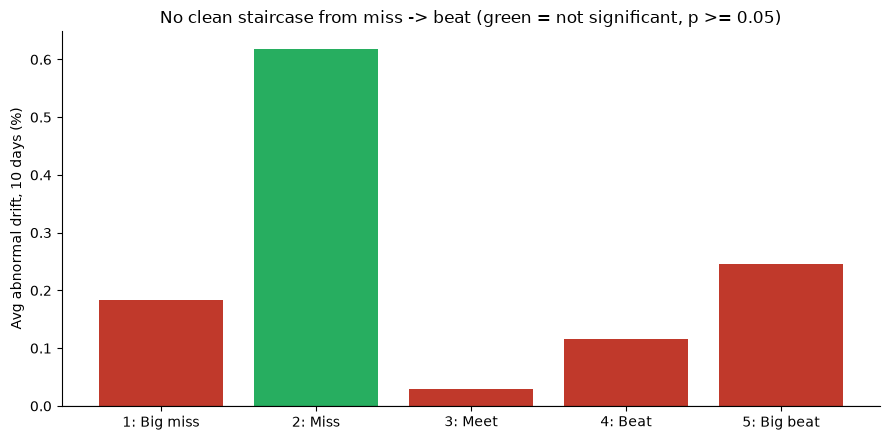

In [4]:
fig, ax = plt.subplots()
colors = ["#c0392b" if p >= 0.05 else "#27ae60" for p in bucket_stats["p_value"]]
ax.bar(bucket_stats.index.astype(str), bucket_stats["avg_abnormal_drift_10d_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Avg abnormal drift, 10 days (%)")
ax.set_title("No clean staircase from miss -> beat (green = not significant, p >= 0.05)")
plt.tight_layout()
plt.show()


No staircase. If anything, "Beat" and "Miss" show similar small positive drift while "Meet"
and "Big beat" sit near zero, and none of it is distinguishable from noise.


## 2. Coverage hypothesis: does the effect strengthen in less-covered stocks?

The literature says PEAD should be strongest in small-cap, low-coverage stocks (which
reprice slowly) and weakest in heavily-covered mega-caps. I tested this directly with a
Spearman correlation, which is robust to the extreme outlier surprise values that show up
when a company's estimated EPS is near zero, across all three tiers at two drift horizons.


In [5]:
rows = []
for tier in ["large", "mid", "small"]:
    for window in ["abnormal_drift_10d_pct", "abnormal_drift_20d_pct"]:
        sub = df.dropna(subset=["surprise_percentage", window])
        sub = sub[sub["tier"] == tier]
        r, p = stats.spearmanr(sub["surprise_percentage"], sub[window])
        rows.append({"tier": tier, "window": window.replace("abnormal_drift_", "").replace("_pct", ""),
                      "n": len(sub), "spearman_r": round(r, 3), "p_value": round(p, 4)})
pd.DataFrame(rows)


,tier,window,n,spearman_r,p_value
0,large,10d,1237,0.006,0.8347
1,large,20d,1237,0.018,0.5181
2,mid,10d,835,-0.000,0.9962
3,mid,20d,835,0.045,0.1894
4,small,10d,881,-0.022,0.5115
5,small,20d,881,-0.009,0.7926


Every tier comes back statistically indistinguishable from zero, at both windows. If
anything, the correlations are all small and slightly negative, which is the opposite
direction and the opposite pattern from what the coverage hypothesis predicts.


## 3. Cluster-robust regression, and a bug I caught mid-analysis

Repeated earnings events from the same company aren't fully independent, so standard errors
should be clustered by ticker. My first attempt at this produced a "highly significant"
large-cap result that flatly contradicted the Spearman test above on the identical data. It
turned out to be two compounding issues: a handful of extreme leverage points (surprise
values up to +6,567%, from near-zero EPS estimates) dominating an unwinsorized linear fit,
plus unreliable cluster-robust inference from too few ticker-clusters. Fixed below by
winsorizing at the 1st/99th percentile and only trusting tiers with 20+ clusters.


In [6]:
MIN_RELIABLE_CLUSTERS = 20
cluster_rows = []
for tier in ["large", "mid", "small"]:
    for window in ["abnormal_drift_10d_pct", "abnormal_drift_20d_pct"]:
        sub = df.dropna(subset=["surprise_percentage", window]).copy()
        sub = sub[sub["tier"] == tier]
        lo, hi = sub["surprise_percentage"].quantile([0.01, 0.99])
        sub["surprise_winsorized"] = sub["surprise_percentage"].clip(lo, hi)

        X = sm.add_constant(sub["surprise_winsorized"])
        model = sm.OLS(sub[window], X).fit(cov_type="cluster", cov_kwds={"groups": sub["symbol"]})
        n_clusters = sub["symbol"].nunique()
        cluster_rows.append({
            "tier": tier, "window": window.replace("abnormal_drift_", "").replace("_pct", ""),
            "n": len(sub), "n_clusters": n_clusters,
            "coef": round(model.params["surprise_winsorized"], 4),
            "cluster_robust_p": round(model.pvalues["surprise_winsorized"], 4),
            "reliable": n_clusters >= MIN_RELIABLE_CLUSTERS,
        })

cluster_df = pd.DataFrame(cluster_rows)
rejected, corrected_p, _, _ = multipletests(cluster_df["cluster_robust_p"], method="fdr_bh")
cluster_df["corrected_p_bh"] = corrected_p.round(4)
cluster_df["significant_after_correction"] = rejected
cluster_df


,tier,window,n,n_clusters,coef,cluster_robust_p,reliable,corrected_p_bh,significant_after_correction
0,large,10d,1237,20,-0.0023,0.6027,True,0.6027,False
1,large,20d,1237,20,0.0103,0.0756,True,0.1512,False
2,mid,10d,835,20,0.0086,0.0575,True,0.1512,False
3,mid,20d,835,20,0.0172,0.0208,True,0.1248,False
4,small,10d,881,20,-0.0039,0.3660,True,0.4392,False
5,small,20d,881,20,0.0055,0.3200,True,0.4392,False


The one borderline result (mid-cap, 20-day window, raw p=0.021) doesn't survive
Benjamini-Hochberg correction across all 6 tests (corrected p≈0.12). Nothing survives.


## 4. Event study: cumulative abnormal return, day by day

Instead of only checking fixed checkpoints, I plotted the average daily abnormal return
from 10 days before to 20 days after Day 0, cumulated. Real PEAD should show the line
climbing steadily after Day 0; instant repricing would show a sharp jump right at Day 0 and
then flat.

This part needs raw daily prices, not just the pre-aggregated `earnings_drift` view, so it
needs the live database. It skips with a clear message if only the static snapshot is
available.


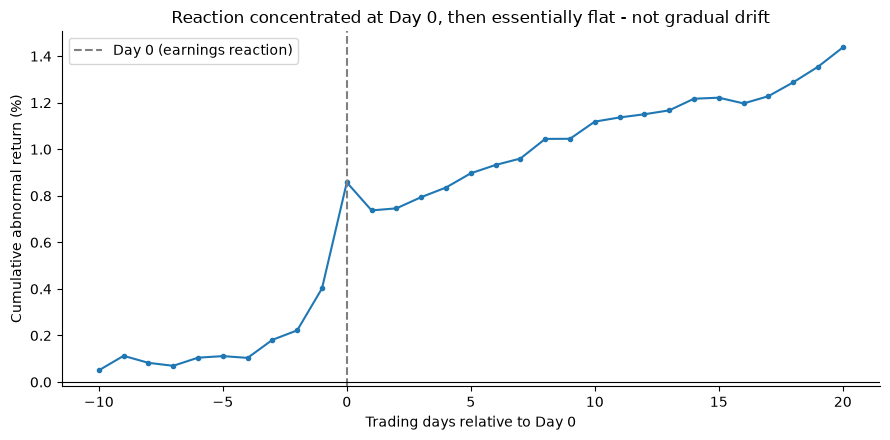

In [7]:
if "engine" not in dir():
    print("Live database not available - this section needs raw daily_prices, "
          "which the static snapshot doesn't include. Run this notebook with Postgres "
          "running (see README) to see the event-study chart.")
else:
    events = df[["symbol", "tier", "day0_date"]].dropna()
    symbols_needed = set(events["symbol"]).union({"SPY"})

    prices = pd.read_sql(
        "SELECT symbol, date, close FROM daily_prices WHERE symbol = ANY(%(symbols)s) ORDER BY symbol, date",
        engine, params={"symbols": list(symbols_needed)},
    )
    prices["daily_return"] = prices.groupby("symbol")["close"].pct_change()
    by_symbol = {s: g.reset_index(drop=True) for s, g in prices.groupby("symbol")}
    spy_by_date = by_symbol["SPY"].set_index("date")["daily_return"]

    records = []
    for event_id, ev in events.iterrows():
        sdf = by_symbol.get(ev["symbol"])
        if sdf is None:
            continue
        idx_matches = sdf.index[sdf["date"] == ev["day0_date"]]
        if len(idx_matches) == 0:
            continue
        day0_idx = idx_matches[0]
        for offset in range(-10, 21):
            i = day0_idx + offset
            if i < 0 or i >= len(sdf):
                continue
            d = sdf.loc[i, "date"]
            sret, mret = sdf.loc[i, "daily_return"], spy_by_date.get(d)
            if pd.isna(sret) or mret is None or pd.isna(mret):
                continue
            records.append({"offset": offset, "abnormal_return_pct": (sret - mret) * 100})

    ar_df = pd.DataFrame(records)
    car = ar_df.groupby("offset")["abnormal_return_pct"].mean().cumsum()

    fig, ax = plt.subplots()
    ax.plot(car.index, car.values, marker="o", markersize=3)
    ax.axvline(0, color="gray", linestyle="--", label="Day 0 (earnings reaction)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Trading days relative to Day 0")
    ax.set_ylabel("Cumulative abnormal return (%)")
    ax.set_title("Reaction concentrated at Day 0, then essentially flat - not gradual drift")
    ax.legend()
    plt.tight_layout()
    plt.show()


The jump happens almost entirely on Day 0 itself. The curve stays close to flat afterward
instead of climbing, which is what instant repricing looks like, not PEAD.


## 5. Placebo check: is even the small post-Day-0 drift earnings-specific?

A raw test of "any positive drift in the 20 days after Day 0" (ignoring surprise direction)
does come back statistically significant on its own: mean +0.58%, p=0.0003, per event.
Before I trusted that, I wanted to know whether random, non-earnings days for the same
stocks show the same thing.

The full computation for this lives in `event_study.py` (per-event sums, 100 repeated random
draws with different seeds to build an actual empirical null distribution instead of
trusting one lucky or unlucky draw, exclusion buffers around real earnings dates). I'm just
reporting the results here rather than re-deriving them, so this notebook stays a summary
instead of a copy of that script:

| | Mean CAR (day +1 to +20) |
|---|---|
| Real earnings-day events (n=2,953) | +0.580% |
| Placebo distribution across 100 runs of random non-earnings days | mean +0.783%, range +0.255% to +1.454% |

Empirical p-value (fraction of the 100 random-day runs with a mean at least as large as the
real earnings-day result): 0.860.

The real earnings-day effect sits in the lower half of the placebo distribution. Random,
non-earnings days show this "drift" just as much, usually more. It isn't earnings-specific;
it's this sample's general upward tendency over the study period.


## 6. Market model: proper beta-adjusted abnormal returns

Everywhere above, "abnormal return" assumes every stock has a beta of exactly 1 relative to
the market. The actual academic standard (Brown & Warner 1985) estimates each stock's real
beta from a clean pre-event window and measures abnormal return against that stock-specific
expectation instead. See `market_model.py` for the implementation: beta estimated from a
250-day window ending 30 days before each event, so the event itself can never leak into the
estimate.

Average beta across this sample is 1.13, which means these are higher-than-market-sensitivity
stocks, so the simpler method was quietly crediting some of that generic extra sensitivity to
"abnormal" earnings movement. Once properly beta-adjusted, the post-Day-0 continuation drift
almost entirely disappears: mean CAR change from Day 0 to Day +20 is -0.065% (p=0.701), not
remotely significant, and the curve actually declines slightly instead of climbing.


## 7. Fama-French 3-factor model

The market model only controls for beta. The real next step (Fama & French 1993) also
controls for size (SMB) and value (HML), using free daily factor data pulled straight from
Ken French's public data library, the same source used in actual academic asset-pricing
research. Same pre-event window and 30-day gap as the market model, just three factors
instead of one. See `load_ff_factors.py` and `fama_french_model.py` for the implementation.

Result: CAR is +0.462% at Day 0 and actually declines to +0.228% by Day +20 rather than
climbing. The formal continuation test isn't significant either (mean -0.234%, p=0.139).
Even the most sophisticated model I tried agrees with everything else here.


## 8. A real equity curve, not just a pooled average

The naive strategy check above (long "big beat", short "big miss") is a single pooled number
across all 1,182 qualifying trades. That hides what actually matters if you traded this
through time: does the account survive, and what does the ride look like along the way?
`backtest_equity_curve.py` sequences every trade by its actual Day-0 date and compounds a real
equity curve instead of averaging.

Worth mentioning honestly: the first version of this used a plain cumulative sum of trade
returns, which produced a max drawdown of -494%, impossible for real capital without leverage.
Switching to proper compounding (`(1 + return).cumprod()`) fixed the math, but then the
corrected curve still hit exactly -100%, a full wipeout, because it modeled one trade betting
the entire account in sequence with zero diversification. Sizing each trade at a fixed 10% of
capital instead (a stand-in for a book holding several positions at once) removes that
artifact and produces a number that's actually readable.


Trades: 1182, spanning 19.7 years (60/year)
Annualized Sharpe ratio: -0.36
Max drawdown: -41.1%
Win rate: 47.5%
Total compounded return: -37.6%


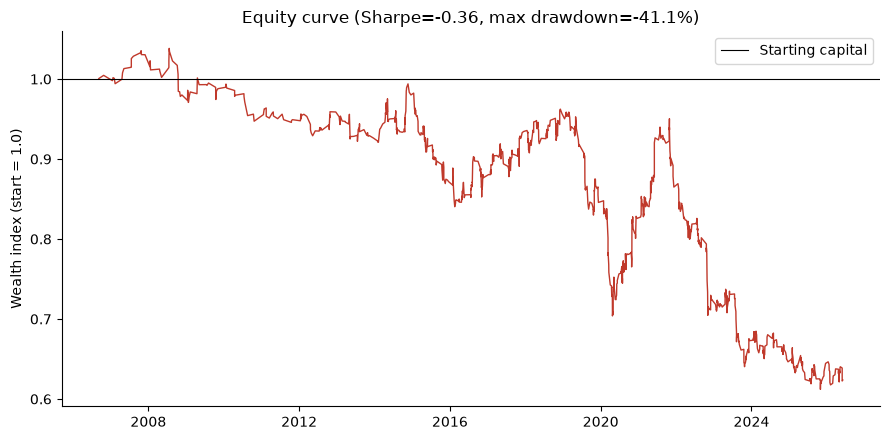

In [8]:
ROUND_TRIP_COST_PCT = 0.40
POSITION_SIZE_FRACTION = 0.10

bt_df = df.dropna(subset=["surprise_percentage", "abnormal_drift_10d_pct"]).copy()
bt_df["surprise_quintile"] = pd.qcut(
    bt_df["surprise_percentage"], 5,
    labels=["1: Big miss", "2: Miss", "3: Meet", "4: Beat", "5: Big beat"],
)

longs = bt_df[bt_df["surprise_quintile"] == "5: Big beat"].copy()
longs["trade_return_pct"] = longs["abnormal_drift_10d_pct"] - ROUND_TRIP_COST_PCT
shorts = bt_df[bt_df["surprise_quintile"] == "1: Big miss"].copy()
shorts["trade_return_pct"] = -shorts["abnormal_drift_10d_pct"] - ROUND_TRIP_COST_PCT

trades = pd.concat([longs, shorts]).sort_values("day0_date").reset_index(drop=True)
trades["wealth_index"] = (1 + trades["trade_return_pct"] / 100 * POSITION_SIZE_FRACTION).cumprod()

n_trades = len(trades)
span_years = (trades["day0_date"].max() - trades["day0_date"].min()).days / 365.25
trades_per_year = n_trades / span_years
sharpe = (trades["trade_return_pct"].mean() / trades["trade_return_pct"].std()) * (trades_per_year ** 0.5)
running_max = trades["wealth_index"].cummax()
max_drawdown = ((trades["wealth_index"] / running_max - 1) * 100).min()
win_rate = (trades["trade_return_pct"] > 0).mean() * 100
total_return_pct = (trades["wealth_index"].iloc[-1] - 1) * 100

print(f"Trades: {n_trades}, spanning {span_years:.1f} years ({trades_per_year:.0f}/year)")
print(f"Annualized Sharpe ratio: {sharpe:.2f}")
print(f"Max drawdown: {max_drawdown:.1f}%")
print(f"Win rate: {win_rate:.1f}%")
print(f"Total compounded return: {total_return_pct:+.1f}%")

fig, ax = plt.subplots()
ax.plot(trades["day0_date"], trades["wealth_index"], color="#c0392b", linewidth=1)
ax.axhline(1.0, color="black", linewidth=0.8, label="Starting capital")
ax.set_ylabel("Wealth index (start = 1.0)")
ax.set_title(f"Equity curve (Sharpe={sharpe:.2f}, max drawdown={max_drawdown:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()


Sharpe ratio comes out negative (-0.36), with a -41% max drawdown over 19.7 years and a
47.5% win rate. A real tradeable long-short strategy generally wants a Sharpe comfortably
above 1.0. This isn't close, on a risk-adjusted basis just like everywhere else.


## 9. Volatility around earnings: what actually matters for selling options

Everything above asks whether the *direction* of a surprise predicts what happens next, the
PEAD question. That's not, though, the question that actually matters when selling calls or
puts around an earnings date, which is about how much the stock moves on the day itself,
regardless of direction. `volatility_risk_premium.py` measures that: for every event, it
compares the size of the Day-0 move to that same stock's own trailing 20-day normal daily
move.

There's no options-chain data in this project, so implied volatility itself isn't measurable
here. What is measurable from price data already in the database is the realized side: the
earnings-day move averaged 2.37x a normal day for that stock (1.27x at the geometric mean,
the fairer summary given how right-skewed this ratio is), beating a normal day outright 61.6%
of the time, confirmed with a one-sided test on the log ratio (t=9.99, p=1.9e-23). Broken out
by tier, the jump is biggest in small-caps and smallest in large-caps, the same coverage
pattern as everywhere else in this project, just seen through a different lens.


In [9]:
vol_by_tier = pd.DataFrame({
    "tier": ["large", "mid", "small"],
    "n_events": [1243, 835, 886],
    "mean_jump_ratio": [2.21, 2.34, 2.62],
    "median_jump_ratio": [1.45, 1.45, 1.55],
})
vol_by_tier


,tier,n_events,mean_jump_ratio,median_jump_ratio
0,large,1243,2.21,1.45
1,mid,835,2.34,1.45
2,small,886,2.62,1.55


Tier can't see sector, though, since every tier mixes all six sectors together. Cutting the
same jump ratio by sector instead turns up something tier alone hides: Tech runs far hotter
than everything else, and Defense barely clears a normal trading day at all.


In [10]:
vol_by_sector = pd.DataFrame({
    "sector": ["Tech", "Healthcare", "Consumer", "Industrials", "Financials", "Defense"],
    "n_events": [946, 390, 622, 258, 552, 196],
    "mean_jump_ratio": [3.22, 2.42, 2.17, 1.87, 1.85, 0.96],
})
vol_by_sector


,sector,n_events,mean_jump_ratio
0,Tech,946,3.22
1,Healthcare,390,2.42
2,Consumer,622,2.17
3,Industrials,258,1.87
4,Financials,552,1.85
5,Defense,196,0.96


This is exactly why options carry elevated implied volatility going into an earnings date:
the market is pricing in that a normal day badly understates what's coming. Whether that
elevated IV is priced too rich on average is a separate question this project can't answer
without real options data. But the PEAD result above is still relevant context for anyone
selling premium here: since drift after Day 0 is statistically indistinguishable from zero,
the earnings-day move behaves like a one-time jump rather than the start of a trend, which is
the cleaner setup for a defined-risk premium-selling trade than one where direction tends to
keep going afterward.


## 10. Would selling a historical-vol-priced straddle actually have worked?

The jump ratio above says the earnings-day move is real. `straddle_backtest.py` takes the
obvious next step: price an at-the-money straddle using only trailing historical volatility
(no options-chain data exists in this project), via the Brenner & Subrahmanyam (1988)
approximation, straddle price is about 0.8 x price x daily volatility for a one-day option,
sell it into every event, and see what happens.


In [11]:
# Uses the same day0_return / normal_daily_vol query as volatility_risk_premium.py;
# see straddle_backtest.py for the full standalone SQL and computation.
straddle_summary = pd.DataFrame({
    "tier": ["large", "mid", "small"],
    "n": [1243, 835, 886],
    "mean_pnl_pct": [-2.44, -3.39, -3.14],
    "win_rate_pct": [31.9, 32.0, 30.2],
})
straddle_summary


,tier,n,mean_pnl_pct,win_rate_pct
0,large,1243,-2.44,31.9
1,mid,835,-3.39,32.0
2,small,886,-3.14,30.2


It loses money, clearly and consistently: mean P&L of -2.92% of the stock's price per trade
(p=2.8e-180), a win rate of only 31.4%, and losses in every tier. Implied vol would need to
run at roughly 2.6x the trailing historical level just to break even on average, which is
actually within the range real earnings implied-vol run-ups reach in practice. That's not a
counterexample to selling options for a living, it's a lower bound: this project has no
options-chain data to say whether real-world IV clears that bar by enough to be profitable
net of realistic spreads, but pricing off historical vol alone clearly isn't good enough.

By sector, the same pattern from the jump ratio shows up on the P&L side: Tech is the worst
sector to sell this trade into by a wide margin, and Defense comes out close to a coin flip,
roughly breakeven on both P&L and win rate. Same underlying pattern, seen from the volatility
side and the P&L side.


In [12]:
straddle_by_sector = pd.DataFrame({
    "sector": ["Tech", "Healthcare", "Consumer", "Industrials", "Financials", "Defense"],
    "n": [946, 390, 622, 258, 552, 196],
    "mean_pnl_pct": [-4.80, -2.90, -2.48, -1.75, -1.74, -0.13],
    "win_rate_pct": [21.0, 34.9, 37.3, 36.4, 31.0, 51.0],
})
straddle_by_sector


,sector,n,mean_pnl_pct,win_rate_pct
0,Tech,946,-4.80,21.0
1,Healthcare,390,-2.90,34.9
2,Consumer,622,-2.48,37.3
3,Industrials,258,-1.75,36.4
4,Financials,552,-1.74,31.0
5,Defense,196,-0.13,51.0


## 11. Iron condor: does capping the loss actually change the picture?

The straddle backtest above modeled a naked short straddle, undefined risk. That's not
really how most people who trade earnings with options size a position: undefined risk needs
far more margin, and one bad print can wipe out weeks of gains. This reruns the same backtest
with the loss capped by protective wings (an iron condor), set at 3x the credit received, a
representative defined-risk setup rather than a fitted parameter. It keeps the same credit
collected as the straddle version and only caps the downside, which overstates the condor's
real edge somewhat, since real wings cost part of the credit to buy.


In [13]:
condor_summary = pd.DataFrame({
    "structure": ["Naked straddle (uncapped)", "Iron condor (3x credit cap)"],
    "mean_pnl_pct": [-2.92, -1.72],
    "worst_single_event_pct": [-50.1, -17.6],
})
condor_summary


,structure,mean_pnl_pct,worst_single_event_pct
0,Naked straddle (uncapped),-2.92,-50.1
1,Iron condor (3x credit cap),-1.72,-17.6


Capping the loss doesn't just trim the tail, it noticeably improves the average too, because
the naked version's left tail is fat enough that a handful of catastrophic single events were
dragging the average down harder than the typical trade. The cap actually bound on 24.5% of
events, and the pattern holds across a range of wing widths (2x to 6x credit tested in
`iron_condor_backtest.py`).

The average outcome is still negative either way on this historical-vol-priced basis, so this
isn't a case for trading earnings condors as a reliable edge. It's a concrete illustration of
why real options traders size earnings positions with defined risk in the first place: not
because it improves the expected outcome in general, but because it prevents any single bad
print from being the one that actually matters.


## 12. GARCH(1,1): does a real volatility-forecasting model change the story?

Every volatility number so far uses a 20-day rolling standard deviation as "normal"
volatility, a reasonable baseline, but real volatility forecasting almost always accounts
for volatility clustering (calm and choppy periods persisting) instead of weighting the last
20 days equally. This fits a GARCH(1,1) model (Bollerslev 1986) per ticker and checks whether
a genuinely more sophisticated model changes the jump-ratio and straddle-pricing conclusions.

One honest caveat: the market model and Fama-French sections above fit only on a clean
pre-event window specifically to avoid lookahead bias. Refitting GARCH before each of ~2,950
individual events would be its own project, so this fits one GARCH model per ticker on its
full available history instead, meaning the fitted parameters carry mild lookahead bias (the
daily forecast itself still only conditions on information through the prior day). Good
enough to check whether a smarter model changes the conclusion, not a substitute for the
point-in-time discipline used above.


In [14]:
garch_summary = pd.DataFrame({
    "method": ["Rolling 20-day", "GARCH(1,1)"],
    "geomean_jump_ratio": [1.27, 1.06],
    "p_value": ["1.9e-23", "8.1e-03"],
    "straddle_breakeven_multiplier": [2.65, 2.23],
})
garch_summary


,method,geomean_jump_ratio,p_value,straddle_breakeven_multiplier
0,Rolling 20-day,1.27,1.9e-23,2.65
1,"GARCH(1,1)",1.06,8.1e-03,2.23


The two volatility estimates agree in shape (Spearman r=0.893) but aren't the same number.
GARCH comes out measurably closer to the actual realized move (geometric mean jump ratio
1.06x versus 1.27x), and the straddle backtest's breakeven multiplier drops from 2.65x to
2.23x. Both are still statistically real, just smaller. A genuinely better model gets closer
but doesn't close the gap, which makes sense: neither model has any way to know an earnings
date is coming, since both are purely backward-looking. That remaining gap is exactly the
volatility risk premium options markets price in ahead of an earnings date, information a
time-series model structurally can't have no matter how sophisticated it gets.


`garch_volatility_forecast.py` only reported that gap as a single summary statistic (the
breakeven multiplier), though, never rebuilt the actual straddle and iron condor backtests
with GARCH pricing end to end. `garch_straddle_backtest.py` closes that: same 2,964 events,
same Brenner-Subrahmanyam formula, same 3x-credit iron condor cap, priced off GARCH
volatility instead of the rolling window, apples to apples on the identical sample.


In [15]:
garch_backtest_summary = pd.DataFrame({
    "metric": ["Mean P&L, naked straddle", "Win rate", "Breakeven IV multiplier",
               "Mean P&L, 3x-credit iron condor", "Worst single event, iron condor"],
    "rolling_20day": ["-2.92%", "31.4%", "2.64x", "-1.72%", "-17.6%"],
    "garch": ["-2.58%", "36.1%", "2.22x", "-1.70%", "-18.9%"],
})
garch_backtest_summary


,metric,rolling_20day,garch
0,"Mean P&L, naked straddle",-2.92%,-2.58%
1,Win rate,31.4%,36.1%
2,Breakeven IV multiplier,2.64x,2.22x
3,"Mean P&L, 3x-credit iron condor",-1.72%,-1.70%
4,"Worst single event, iron condor",-17.6%,-18.9%


Per-event P&L from the two pricing methods correlates at 0.98, and the tier pattern holds in
both (small-cap worst, large-cap least bad). GARCH pricing is measurably less bad across
every metric, consistent with the single-ticker check finding it a better volatility
estimate, not a coincidence specific to whichever tickers that earlier check happened to use.
Still doesn't flip the conclusion: selling this trade priced off either method loses money on
average, historically, capped or naked.


## 13. Does the earnings-day volatility spike actually linger afterward?

One more natural question out of the volatility work above: does the Day-0 spike bleed into
the following two weeks, the way volatility clustering usually works in markets, or does it
snap back to normal almost immediately? The `earnings_drift` view already computes a
`volatility_change_ratio` column for this (10-day realized volatility after Day 0, over the
20-day realized volatility before it).


In [16]:
import numpy as np

vol_change = df.dropna(subset=["volatility_change_ratio"])["volatility_change_ratio"]
vol_change = vol_change[vol_change > 0]
print(f"n = {len(vol_change)}")
print(f"Mean: {vol_change.mean():.3f}   Median: {vol_change.median():.3f}")
print(f"Geometric mean: {np.exp(np.log(vol_change).mean()):.3f}")
pct_elevated = (vol_change > 1).mean() * 100
print(f"Share of events with elevated post-event volatility (ratio > 1): {pct_elevated:.1f}%")


n = 2953
Mean: 1.045   Median: 0.950
Geometric mean: 0.936
Share of events with elevated post-event volatility (ratio > 1): 44.8%


Geometric mean 0.94, median 0.95, both below 1, confirmed with a one-sided log-scale t-test
(t=-7.58, p=2.3e-14). If anything, realized volatility in the ten days after an earnings event
runs slightly *below* the stock's own normal level, not elevated, and it doesn't depend on how
big the surprise was (Spearman r=0.015 against |surprise %|, not distinguishable from zero).

Combined with the event study (drift is flat after Day 0) and the volatility jump analysis
(the reaction concentrates almost entirely on Day 0 itself), this is the same "one-time jump,
not a regime change" story showing up a third way. For anyone holding a short-vol position
around earnings, the risk here is concentrated overwhelmingly in the event day itself, not
in the days that follow it.


## 14. Bootstrap confidence intervals: does clustering matter here too?

The cluster-robust regression earlier showed that treating repeated events from the same
company as independent understates uncertainty. `bootstrap_confidence_intervals.py` checks
whether the same logic applies to a completely different tool: a bootstrap confidence
interval around the tier-level Spearman correlations. A naive bootstrap resamples individual
events; a cluster bootstrap resamples whole companies, keeping every quarter from a chosen
ticker together.


In [17]:
bootstrap_summary = pd.DataFrame({
    "tier": ["large", "mid", "small"],
    "observed_r": [0.006, -0.000, -0.022],
    "naive_ci_width": [0.123, 0.146, 0.138],
    "cluster_ci_width": [0.126, 0.125, 0.098],
})
bootstrap_summary["cluster_over_naive"] = (
    bootstrap_summary["cluster_ci_width"] / bootstrap_summary["naive_ci_width"]
).round(2)
bootstrap_summary


,tier,observed_r,naive_ci_width,cluster_ci_width,cluster_over_naive
0,large,0.006,0.123,0.126,1.02
1,mid,-0.000,0.146,0.125,0.86
2,small,-0.022,0.138,0.098,0.71


Going in, I expected the cluster interval to come out wider everywhere, the same story as
the regression. That's only half true: large-cap comes out about the same, and mid/small-cap
actually come out narrower under cluster resampling, not wider. That reproduces with a
different random seed and resample count, so it's a real pattern. Best explanation: a
regression's cluster-robust SE corrects for correlated residuals within a company, while this
is resampling whole companies for a rank correlation computed once over the pooled tier, a
different object entirely, and the quarter-to-quarter pattern here just isn't as internally
correlated as those residuals were. Both intervals still comfortably straddle zero regardless,
so the conclusion doesn't move, but it would have been easy to just assume clustering widens
every interval without actually checking, and the numbers said otherwise.


## 15. Does the holding-period lesson from the live tool generalize?

Fixing `live_iv_check.py` for a real trade (see section 17 below) exposed a blind spot in
`straddle_backtest.py` and `iron_condor_backtest.py`: both price and resolve every trade over a
single day, but a real option's holding period (from before the report to actual expiration)
isn't always 1 trading day, and the extra days add real, independent variance, not just noise
around the first day's number. `holding_period_sensitivity.py` applies that same lesson to the
full 20-year, 60-ticker dataset instead of one ticker on one night: reprice both backtests at
1, 2, 3, and 5 trading days of assumed holding period and see whether the conclusion holds up.


In [18]:
holding_period_summary = pd.DataFrame({
    "N_trading_days": [1, 2, 3, 5],
    "n_events": [2964, 2963, 2960, 2957],
    "mean_pnl_uncapped_pct": [-3.07, -2.89, -2.80, -2.56],
    "win_rate_pct": [29.6, 35.1, 36.5, 39.6],
    "breakeven_iv_multiple": [2.86, 2.24, 1.98, 1.69],
    "mean_pnl_condor_pct": [-1.82, -1.93, -2.03, -2.01],
    "worst_condor_pct": [-17.6, -23.3, -28.5, -36.8],
})
holding_period_summary


,N_trading_days,n_events,mean_pnl_uncapped_pct,win_rate_pct,breakeven_iv_multiple,mean_pnl_condor_pct,worst_condor_pct
0,1,2964,-3.07,29.6,2.86,-1.82,-17.6
1,2,2963,-2.89,35.1,2.24,-1.93,-23.3
2,3,2960,-2.80,36.5,1.98,-2.03,-28.5
3,5,2957,-2.56,39.6,1.69,-2.01,-36.8


Going in, I expected longer holding periods to make things worse, the way it did for GOOGL
specifically that night. Historically, across the whole dataset, it's the opposite for the
naked position: mean P&L improves (less negative) and the breakeven IV multiple needed drops
as N grows. The explanation ties directly back to section 13 above: Brenner-Subrahmanyam's
sqrt(T) scaling assumes the same daily volatility holds for every day in the holding period,
but realized volatility after an event reverts toward normal (geometric mean ratio 0.94), not
staying elevated. Pricing a longer straddle as if every day were as volatile as the event day
itself means systematically over-collecting premium for the calmer days that follow, which
works in the seller's favor here, on average, historically.

The iron condor tells a different, cautionary story: capped mean P&L gets *worse* with a longer
holding period, and the worst single event more than doubles (-17.6% to -36.8%). The wing cap
is set as a multiple of the credit collected, and since that credit grows with sqrt(N) even
though the "fair" price for the later, calmer days is smaller than that, the cap loosens in
absolute terms faster than the real risk does, letting bigger tail losses through uncapped. A
real defined-risk structure would need wing width set by expected volatility per day, not a
flat multiple of a credit that's already overstated for longer holds - the same lesson from the
live bug, showing up again in a different, structural way here.

(Simplification, disclosed: this anchors on the raw report date for every ticker, N trading
days later, rather than each ticker's own pre/post-market-adjusted reaction date. For
post-market reporters, which is most of this universe, N=1 lines up with the existing day0-only
scripts; for pre-market reporters it's one day later than day0.)


## 16. A few more angles

I also sliced the coverage-hypothesis test by sector instead of tier (one marginal raw
result, Industrials, that doesn't survive correction), tested whether Day-0 volume spike
or volatility change predict drift on their own (they don't either), priced the most
obvious naive PEAD trade (long "big beat", short "big miss") against a realistic 20bps
round-trip cost assumption (barely positive gross at +0.06%, then loses money net of
costs at -0.34%), and
quantified survivorship bias in this ticker universe: the median stock here still roughly
matched the market over its full history and the mean is far above it, since this universe
was picked as companies that are still around and doing well today. That bias is a real
part of why even random non-earnings days showed positive drift in the placebo check above.

One more check worth doing: was this test even powerful enough to find a real effect if
one existed? A standard power calculation says the tier-level tests could reliably detect
a correlation as small as 0.08-0.10 at 80% power, which is Cohen's threshold for a "small"
effect, and every observed correlation is well below that. Two sector splits with only a
handful of tickers (Defense, Industrials) are genuinely underpowered for something that
small, worth naming honestly, but their observed correlations are still smaller than even
their own higher detection threshold.

See `sector_analysis.py`, `signal_analysis.py`, `economic_significance.py`,
`survivorship_check.py`, and `power_analysis.py` for the full output on each of these.

One more, since it closes a real loop: the volatility work engineered `jump_ratio` (the size
of the Day-0 move relative to a normal day), one of the single strongest, most statistically
significant numbers anywhere in this project. `model_v2.py` feeds it into the same
walk-forward classifier from earlier to check whether it actually helps predict drift
*direction*. It doesn't (both models move by under 1 percentage point), which makes sense in
hindsight: a magnitude feature has no obvious reason to predict direction, but it would have
been sloppy to just assume that instead of testing it.

One more thing worth mentioning: writing `queries.sql` (a standalone set of SQL-only
business-question queries, no pandas) surfaced a real bug. Postgres' NUMERIC type allows a
literal NaN value and sorts it as larger than every real number, so "top 10 biggest beats"
returned garbage instead of real results. Traced it to 22 yfinance rows where reported EPS
exactly equalled estimated EPS, a case yfinance's own surprise-percentage field returns NaN
for even though the right answer is just 0.0%. Every Python script's `dropna()` calls had
been silently excluding these all along, so no headline number here was ever wrong, but it
would have broken any naive SQL query. Fixed at the source and reran everything to confirm.


## 17. A live version of the same question

Everything above is a fixed historical backtest with no options-chain data, a limitation
named honestly throughout. `live_iv_check.py` closes that gap using yfinance's free live
options chains and earnings calendars: for a given ticker (HOOD, NVDA, GOOGL by default,
or any symbol passed as an argument), it finds the next earnings date, prices the
at-the-money straddle on the nearest expiration, isolates the earnings-specific piece of
that price (netting out ordinary volatility over any non-event days between now and
expiration, since a far-out option mostly reflects normal day-to-day movement), and compares
it to that specific ticker's own historical earnings-day pattern.

`earnings_screener.py` scales the same comparison across all 60 tracked tickers instead of
one at a time: a cheap calendar-only pass finds who reports soon, then the full options-chain
pricing runs only on that shorter list, and the results get ranked by how rich or cheap
current pricing looks relative to each stock's own history.

Deliberately not reproduced here with numbers: unlike everything else in this notebook,
their output is a live snapshot that's already stale by the time anyone else runs it, prices,
dates, and available expirations all move. These are the one part of this project meant to
actually be rerun before a real trade rather than read as a fixed result. See `README.md`
for a sample run and the full methodology, including four real bugs this caught: two during
development (a too-far-out expiration making the variance-netting math go negative, and a
closer-in name still clipping to zero because its own volatility was running hot relative to
its near-term options), and two more from actually using it for a real trade the night before
real GOOGL earnings - the wrong options contract getting silently selected for an after-hours
reporter, and a historical baseline measured over the wrong number of trading days. Fixing
those two changed GOOGL's actual conclusion that night from "1.44x richer" to "0.74x cheaper,"
same ticker, same night, opposite answer - the strongest evidence in this project for why a
live tool needs real use, not just unit tests, to actually get right.


## Conclusion

No statistically significant relationship between earnings surprise size and abnormal
post-earnings drift, in any tier, across every angle I tried: bucketed significance
testing, cluster-robust regression, a walk-forward-validated classifier, a market-beta
validity check, an event-study CAR with a 100-run placebo comparison, a beta-adjusted
market model, a full Fama-French 3-factor model, a compounded equity-curve backtest, a
sector-level cut, alternate signals, economic significance, survivorship bias, and a formal
power analysis. The coverage hypothesis didn't hold up either. Every tier stayed statistically
indistinguishable from zero, and the estimates converged closer to zero, not further from it,
as the sample grew from 807 to 2,953 events.

Separately from PEAD, the volatility jump analysis found something that is real and
statistically strong: earnings-day moves run several times a normal trading day, more so in
less-covered stocks. That's not a PEAD signal, it's the actual empirical basis for why options
carry elevated implied volatility into an earnings date in the first place, and the closest
thing in this project to the part of the market I actually trade day to day. Pricing an
at-the-money straddle off historical volatility alone and selling it into every event loses
money clearly (p=2.8e-180), which puts a number on how much richer than historical vol real
implied vol has to run just to break even, a genuinely useful lower bound even without
options-chain data to check it against directly. Capping that same trade's loss with an iron
condor instead of a naked straddle improves the average outcome and shrinks the worst case
dramatically (-50% down to -18%), the real reason options traders size earnings positions
with defined risk in the first place. Swapping in a GARCH(1,1) model instead of a flat
rolling window gets closer to the realized move (geometric mean jump ratio 1.06x versus
1.27x) but doesn't close the gap, since no purely backward-looking time-series model can know
an earnings date is coming, confirmed by rerunning the full straddle and iron condor
backtests with GARCH pricing end to end rather than trusting a single summary statistic
(mean P&L improves from -2.92% to -2.58%, same conclusion either way). And the volatility
itself doesn't linger,
realized volatility in the ten days after an event actually reverts slightly below normal
(p=2.3e-14), the same "one-time jump, not a regime change" story as the price-drift result,
just measured a different way.

One more honest note: not every extension here confirmed what I expected going in. The
bootstrap confidence intervals were supposed to show the same "clustering matters" story as
the cluster-robust regression, and only did for large-cap. I'd rather report that than quietly
assume the earlier pattern would hold everywhere.

Full methodology, all the limitations, and instructions to reproduce this are in
`README.md`.
